<a href="https://colab.research.google.com/github/vijaydevverse/eda-ml-projects/blob/main/SpotifyUserBehaviorEdaV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [48]:
df=pd.read_csv('/content/spotify_user_behavior_realistic_50000_rows.csv')
df

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,India,33,2022-09-23,Free,Active,2,0,Yes,No,5,11.83,Latin,Offline Mode,Concert Alerts,Tablet,8,5
49996,49997,Italy,35,2023-11-17,Premium Family,Active,0,0,No,No,4,8.01,Latin,Podcasts,Mood-based Auto Playlists,Car System,11,10
49997,49998,Brazil,33,2024-11-14,Premium Individual,Active,0,0,No,No,2,14.47,Rock,Lyrics,Lyrics Translation,Smart Speaker,9,13
49998,49999,USA,43,2021-05-31,Free,Active,0,0,No,No,5,21.86,Indie,AI DJ,Social Listening,Mobile,9,12


In [49]:
df.isnull().sum()

,0
user_id,0
country,0
age,0
signup_date,0
subscription_type,0
subscription_status,0
months_inactive,0
inactive_3_months_flag,0
ad_interaction,0
ad_conversion_to_subscription,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.shape

(50000, 18)

In [53]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [54]:
df["country"].unique()

array(['France', 'Indonesia', 'Italy', 'Australia', 'India', 'Germany',
       'UK', 'Brazil', 'Canada', 'Mexico', 'USA', 'Spain'], dtype=object)

In [55]:
df["subscription_type"].unique()

array(['Premium Duo', 'Premium Family', 'Premium Individual', 'Free',
       'Student'], dtype=object)

In [56]:
df["subscription_status"].unique()

array(['Active', 'Inactive'], dtype=object)

In [57]:
df["ad_interaction"].unique()

array(['No', 'Yes'], dtype=object)

In [58]:
df["ad_conversion_to_subscription"].unique()

array(['No', 'Yes'], dtype=object)

In [59]:
df["favorite_genre"].unique()

array(['Bollywood', 'Latin', 'Electronic', 'Indie', 'Pop', 'Rock',
       'Classical', 'Country', 'K-Pop', 'R&B', 'Jazz', 'Hip-Hop'],
      dtype=object)

In [60]:
df["most_liked_feature"].unique()

array(['Radio', 'Podcasts', 'Lyrics', 'Playlists', 'Daily Mix', 'AI DJ',
       'Discover Weekly', 'Offline Mode'], dtype=object)

In [61]:
df["desired_future_feature"].unique()

array(['Concert Alerts', 'Lyrics Translation',
       'Better AI Recommendations', 'Social Listening', 'HiFi Audio',
       'Mood-based Auto Playlists'], dtype=object)

In [62]:
df["primary_device"].unique()

array(['Tablet', 'Mobile', 'Desktop', 'Smart Speaker', 'Car System'],
      dtype=object)

In [63]:
df.drop("user_id",axis=1,inplace=True)

In [64]:
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["signup_year"]=df["signup_date"].dt.year
df["signup_month"]=df["signup_date"].dt.month
df["signup_day"]=df["signup_date"].dt.day

In [65]:
df["subscription_status"].replace(["Inactive","Active"],[0,1],inplace=True)

/tmp/ipykernel_13733/1271516536.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["subscription_status"].replace(["Inactive","Active"],[0,1],inplace=True)
/tmp/ipykernel_13733/1271516536.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["subscription_status"].replace(["Inactive","Active"],

In [66]:
df["ad_interaction"].replace(["No","Yes"],[0,1],inplace=True)

/tmp/ipykernel_13733/1189929823.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ad_interaction"].replace(["No","Yes"],[0,1],inplace=True)
/tmp/ipykernel_13733/1189929823.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ad_interaction"].replace(["No","Yes"],[0,1],inplace=True)


In [67]:
df["ad_conversion_to_subscription"].replace(["No","Yes"],[0,1],inplace=True)

/tmp/ipykernel_13733/2410233533.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ad_conversion_to_subscription"].replace(["No","Yes"],[0,1],inplace=True)
/tmp/ipykernel_13733/2410233533.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ad_conversion_to_subscription"].replace(["No","Yes"

In [68]:
le=LabelEncoder()

df["country"]=le.fit_transform(df["country"])
df["subscription_type"]=le.fit_transform(df["subscription_type"])
df["favorite_genre"]=le.fit_transform(df["favorite_genre"])
df["most_liked_feature"]=le.fit_transform(df["most_liked_feature"])
df["desired_future_feature"]=le.fit_transform(df["desired_future_feature"])
df["primary_device"]=le.fit_transform(df["primary_device"])

In [69]:
df.drop("signup_date",axis=1,inplace=True)

In [70]:
df

,country,age,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,signup_year,signup_month,signup_day
0,3,25,1,1,0,0,0,0,4,10.13,0,7,1,4,7,8,2021,8,19
1,6,20,2,1,0,0,1,0,5,11.63,8,6,3,2,7,6,2022,6,6
2,7,53,3,1,0,0,1,1,3,9.50,0,3,0,1,6,5,2024,1,4
3,7,48,3,1,1,0,0,0,4,13.16,3,5,5,3,11,8,2018,8,26
4,0,18,0,1,0,0,0,0,4,12.70,5,1,3,4,10,11,2020,5,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,33,0,1,2,0,1,0,5,11.83,8,4,1,4,8,5,2022,9,23
49996,7,35,2,1,0,0,0,0,4,8.01,8,6,4,0,11,10,2023,11,17
49997,1,33,3,1,0,0,0,0,2,14.47,11,3,3,3,9,13,2024,11,14
49998,11,43,0,1,0,0,0,0,5,21.86,5,0,5,2,9,12,2021,5,31


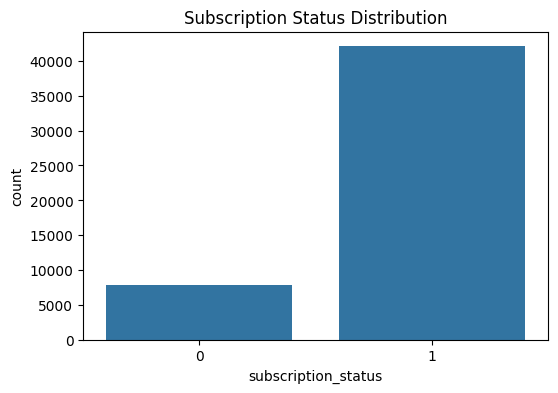

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x="subscription_status",data=df)
plt.title("Subscription Status Distribution")
plt.show()

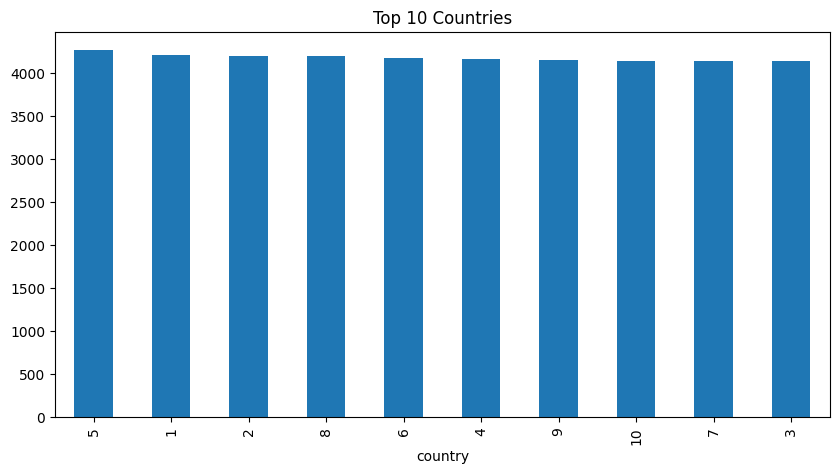

In [72]:
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

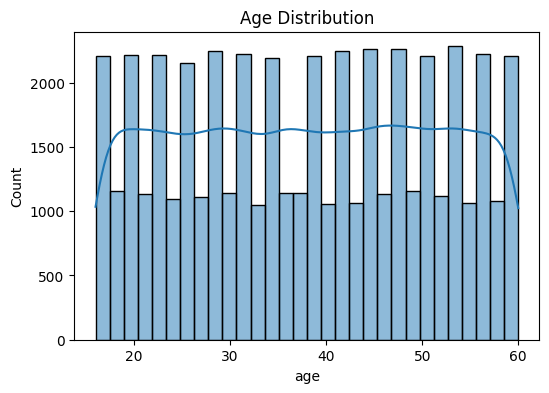

In [73]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

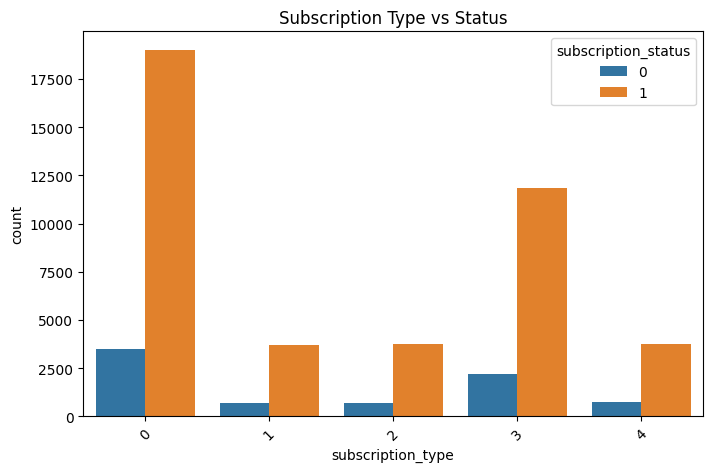

In [74]:
plt.figure(figsize=(8,5))
sns.countplot(x="subscription_type",hue="subscription_status",data=df)
plt.xticks(rotation=45)
plt.title("Subscription Type vs Status")
plt.show()

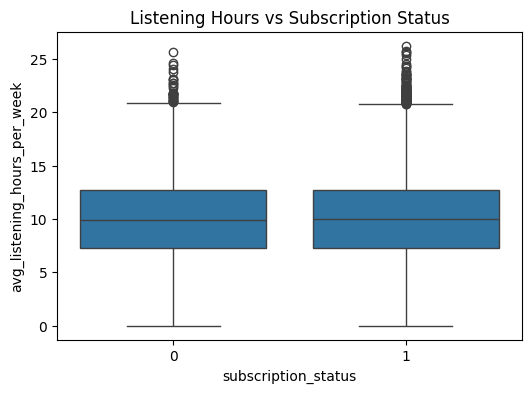

In [75]:
plt.figure(figsize=(6,4))
sns.boxplot(x="subscription_status",y="avg_listening_hours_per_week",data=df)
plt.title("Listening Hours vs Subscription Status")
plt.show()

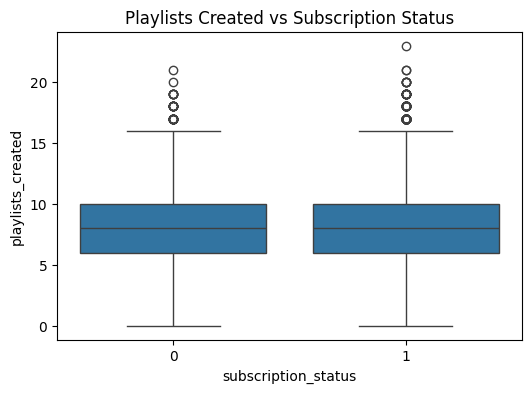

In [76]:
plt.figure(figsize=(6,4))
sns.boxplot(x="subscription_status",y="playlists_created",data=df)
plt.title("Playlists Created vs Subscription Status")
plt.show()

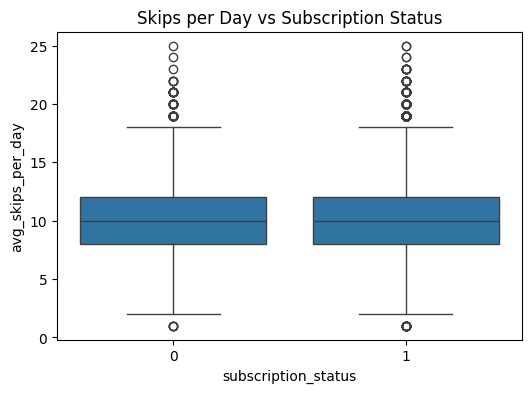

In [77]:
plt.figure(figsize=(6,4))
sns.boxplot(x="subscription_status",y="avg_skips_per_day",data=df)
plt.title("Skips per Day vs Subscription Status")
plt.show()

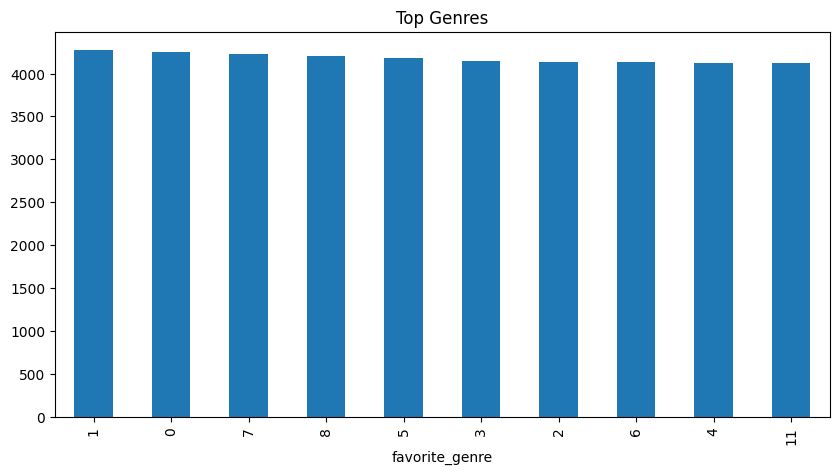

In [78]:
plt.figure(figsize=(10,5))
df["favorite_genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top Genres")
plt.show()

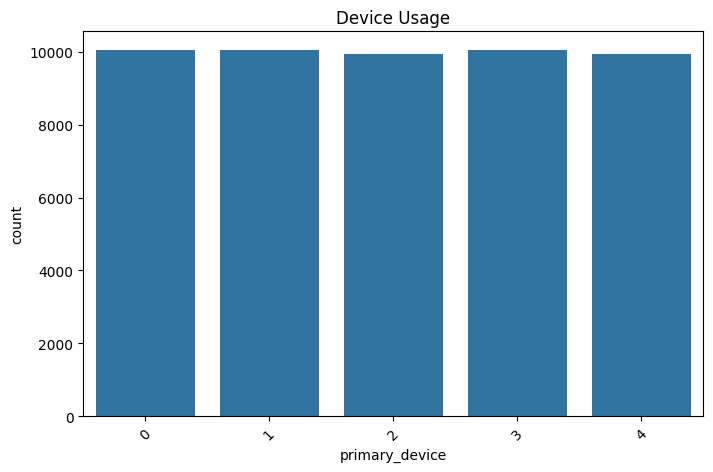

In [79]:
plt.figure(figsize=(8,5))
sns.countplot(x="primary_device",data=df)
plt.xticks(rotation=45)
plt.title("Device Usage")
plt.show()

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         50000 non-null  int64  
 1   age                             50000 non-null  int64  
 2   subscription_type               50000 non-null  int64  
 3   subscription_status             50000 non-null  int64  
 4   months_inactive                 50000 non-null  int64  
 5   inactive_3_months_flag          50000 non-null  int64  
 6   ad_interaction                  50000 non-null  int64  
 7   ad_conversion_to_subscription   50000 non-null  int64  
 8   music_suggestion_rating_1_to_5  50000 non-null  int64  
 9   avg_listening_hours_per_week    50000 non-null  float64
 10  favorite_genre                  50000 non-null  int64  
 11  most_liked_feature              50000 non-null  int64  
 12  desired_future_feature          

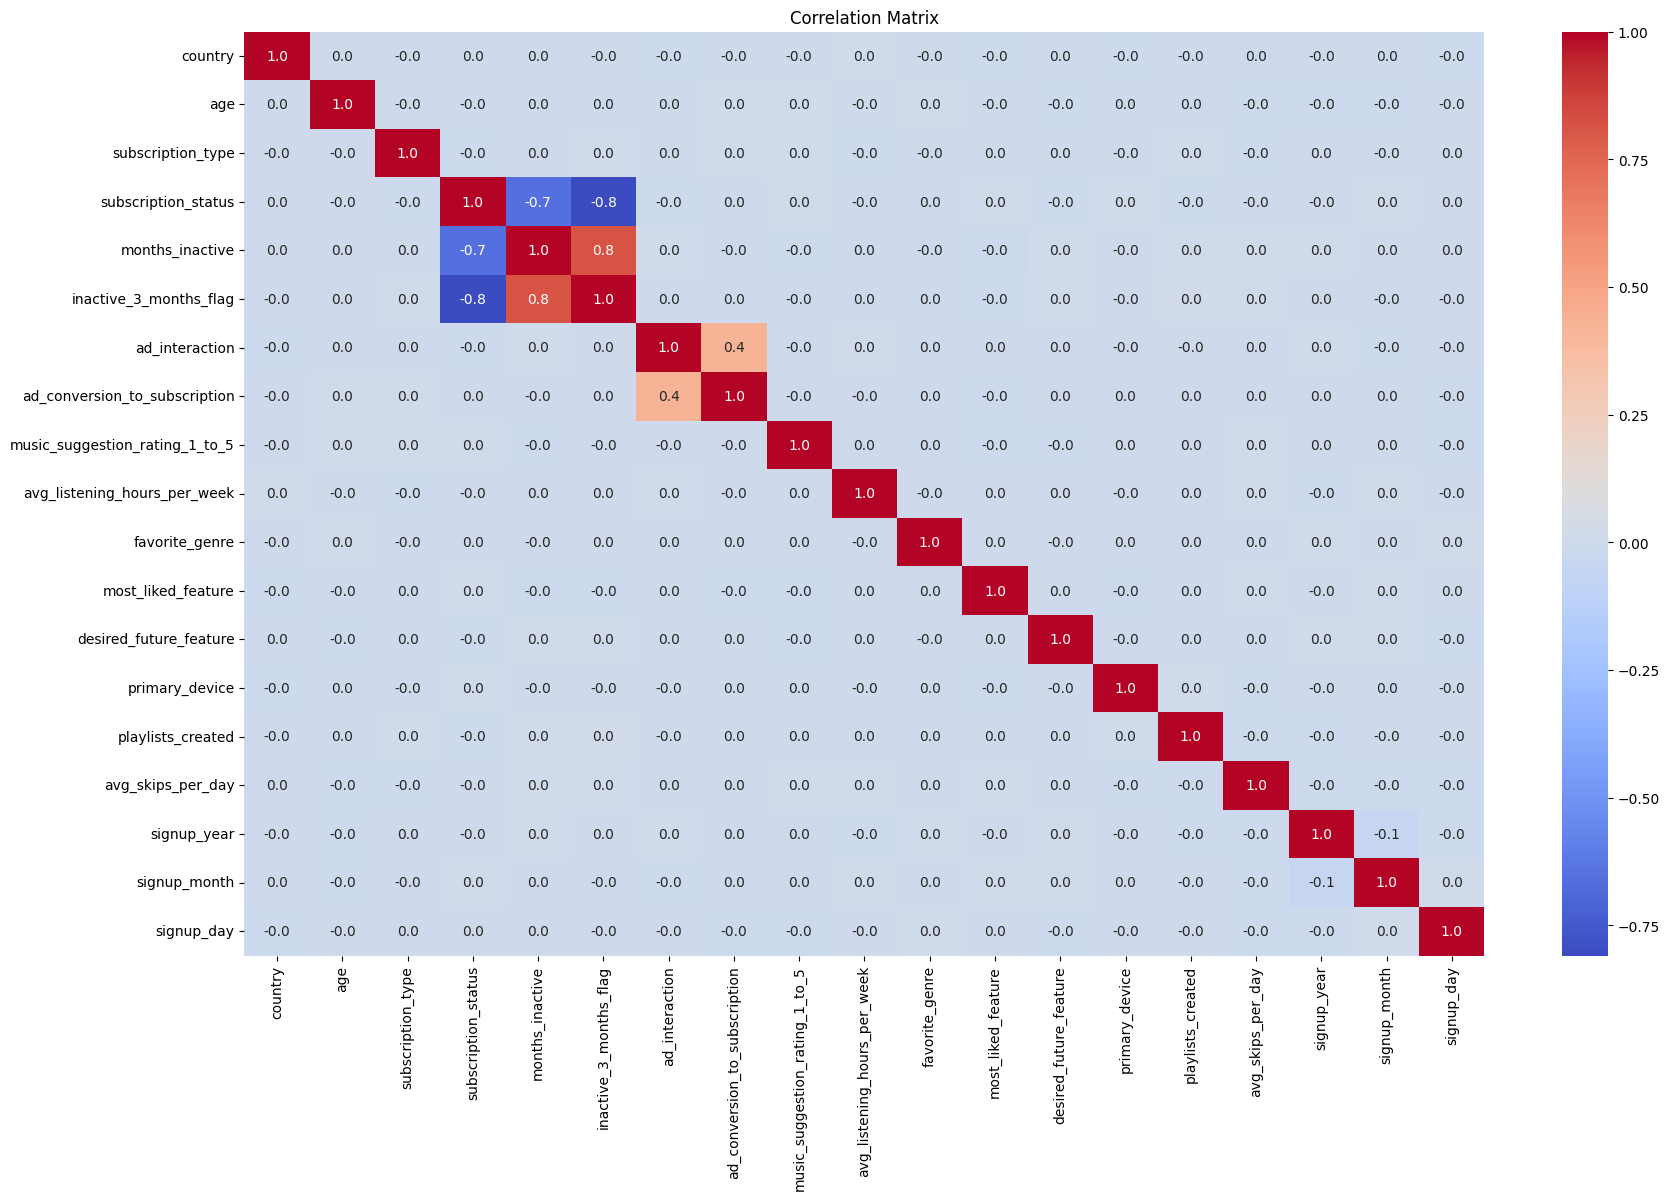

In [81]:
plt.figure(figsize=(20,12))
cm=df.corr()
sns.heatmap(cm,annot=True,fmt=".1f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [82]:
df.drop(["inactive_3_months_flag"],axis=1,inplace=True)

In [83]:
df

,country,age,subscription_type,subscription_status,months_inactive,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,signup_year,signup_month,signup_day
0,3,25,1,1,0,0,0,4,10.13,0,7,1,4,7,8,2021,8,19
1,6,20,2,1,0,1,0,5,11.63,8,6,3,2,7,6,2022,6,6
2,7,53,3,1,0,1,1,3,9.50,0,3,0,1,6,5,2024,1,4
3,7,48,3,1,1,0,0,4,13.16,3,5,5,3,11,8,2018,8,26
4,0,18,0,1,0,0,0,4,12.70,5,1,3,4,10,11,2020,5,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,33,0,1,2,1,0,5,11.83,8,4,1,4,8,5,2022,9,23
49996,7,35,2,1,0,0,0,4,8.01,8,6,4,0,11,10,2023,11,17
49997,1,33,3,1,0,0,0,2,14.47,11,3,3,3,9,13,2024,11,14
49998,11,43,0,1,0,0,0,5,21.86,5,0,5,2,9,12,2021,5,31


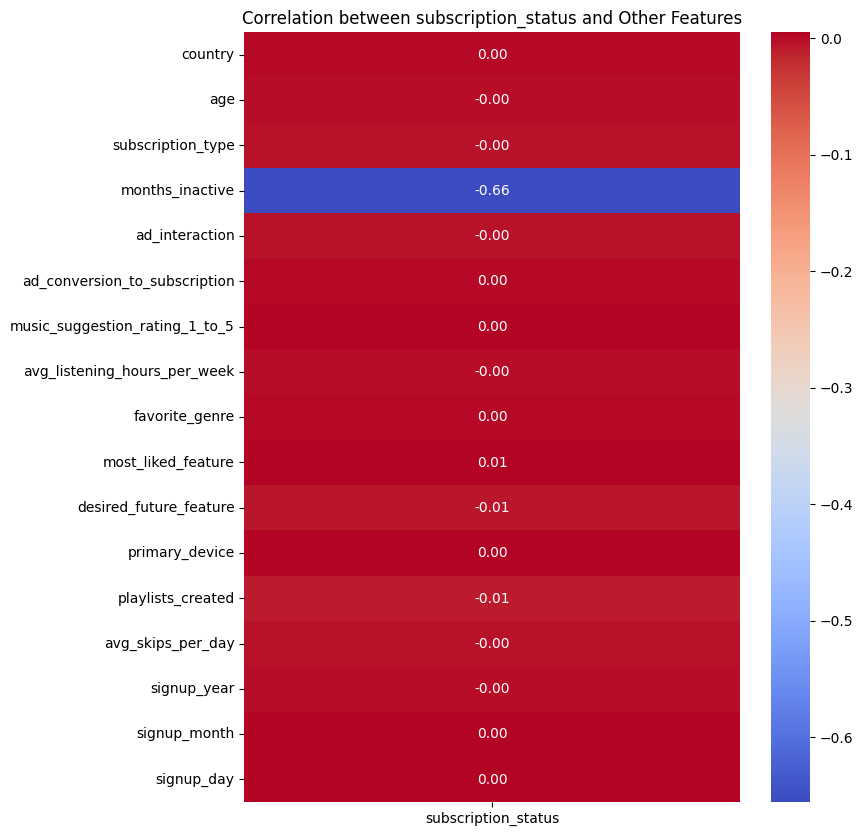

In [84]:
target_corr=df.corr()["subscription_status"]
target_corr=target_corr.drop("subscription_status")

plt.figure(figsize=(8,10))
sns.heatmap(target_corr.to_frame(),annot=True,fmt=".2f",cmap="coolwarm",
            cbar=True,annot_kws={"size":10})
plt.title("Correlation between subscription_status and Other Features")
plt.show()

<Axes: >

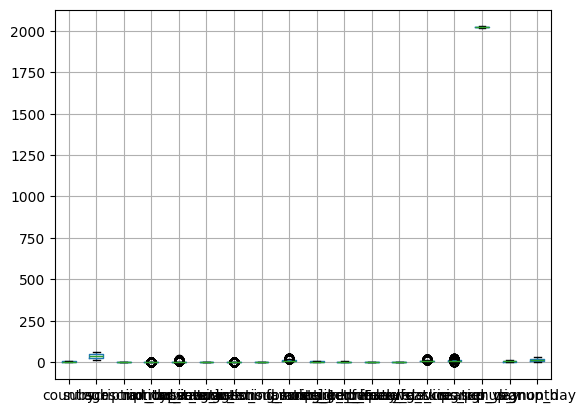

In [85]:
df.boxplot()

In [86]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='loan_status')
df=df_cleaned

In [87]:
df.shape

(34988, 18)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34988 entries, 0 to 49997
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34988 non-null  int64  
 1   age                             34988 non-null  int64  
 2   subscription_type               34988 non-null  int64  
 3   subscription_status             34988 non-null  int64  
 4   months_inactive                 34988 non-null  int64  
 5   ad_interaction                  34988 non-null  int64  
 6   ad_conversion_to_subscription   34988 non-null  int64  
 7   music_suggestion_rating_1_to_5  34988 non-null  int64  
 8   avg_listening_hours_per_week    34988 non-null  float64
 9   favorite_genre                  34988 non-null  int64  
 10  most_liked_feature              34988 non-null  int64  
 11  desired_future_feature          34988 non-null  int64  
 12  primary_device                  34988

In [89]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=["age","months_inactive","music_suggestion_rating_1_to_5","avg_listening_hours_per_week","playlists_created","avg_skips_per_day"]

scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)
scaled_df.head()

,age,months_inactive,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
0,0.204545,0.0,0.75,0.488193,0.4375,0.3750
1,0.090909,0.0,1.00,0.560482,0.4375,0.2500
2,0.727273,0.5,0.75,0.634217,0.6875,0.3750
3,0.045455,0.0,0.75,0.612048,0.6250,0.5625
4,0.613636,0.0,0.75,0.602892,0.1875,0.5000


In [90]:
df

,country,age,subscription_type,subscription_status,months_inactive,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,signup_year,signup_month,signup_day
0,3,25,1,1,0,0,0,4,10.13,0,7,1,4,7,8,2021,8,19
1,6,20,2,1,0,1,0,5,11.63,8,6,3,2,7,6,2022,6,6
3,7,48,3,1,1,0,0,4,13.16,3,5,5,3,11,8,2018,8,26
4,0,18,0,1,0,0,0,4,12.70,5,1,3,4,10,11,2020,5,29
5,3,43,1,1,0,0,0,4,12.51,3,0,0,0,3,10,2018,12,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49992,9,57,2,1,1,1,0,5,9.63,8,3,1,2,7,5,2018,7,31
49994,3,54,3,1,1,1,0,3,11.16,0,2,3,1,13,18,2021,8,23
49995,5,33,0,1,2,1,0,5,11.83,8,4,1,4,8,5,2022,9,23
49996,7,35,2,1,0,0,0,4,8.01,8,6,4,0,11,10,2023,11,17


In [91]:
print(df["subscription_status"].value_counts())

subscription_status
1    34988
Name: count, dtype: int64


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
df['target']=df['months_inactive'].apply(lambda x:0 if x==0 else 1)
X=df[["age","music_suggestion_rating_1_to_5","avg_listening_hours_per_week"]]
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.49
